this was the first script with random sampling in each fold,
10 folds with 20% of test sequences in each fold,
thus joining all the test results have repeated sequences


In [16]:
import os

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split


# Splits generation
...and distribution analysis

In [90]:
DATA_PATH = "/home/gkulemeyer/Documents/Repos/RNA-analysis/DataAnalysis/data/"

In [91]:
ArchiveII_path = DATA_PATH + "sources/ArchiveII.csv"
dataset = pd.read_csv(ArchiveII_path, index_col="id")
dataset = dataset[['sequence', 'structure', 'base_pairs', 'len']]
 
struc_dist = pd.read_hdf(DATA_PATH + "rnadist_f_all.h5") # IDscore
struc_dist /= struc_dist.max().max()
struc_sim = 1 - struc_dist

In [92]:
seq_sim = pd.read_hdf(DATA_PATH + "seqsim_f_all.h5") # IDscore

MAX_L = 512 # <<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<
upto = list(dataset.loc[dataset.len < MAX_L].index) # <<< =<
dataset = dataset.loc[upto]
struc_sim = struc_sim.loc[upto,upto] 
seq_sim = seq_sim.loc[upto, upto]

Text(0.5, 1.0, 'Amount of row with all columns below a given threshold')

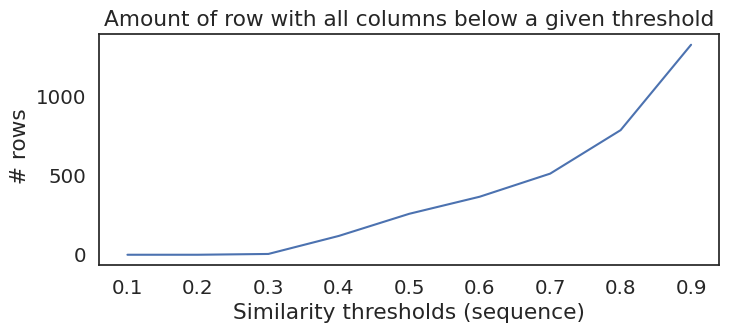

In [95]:
thresholds = np.linspace(0, 1, 11)[1:-1]

seq_sim.values[tuple([range(len(seq_sim))]*2)] = 0
plt.figure(figsize=(8,3))
plt.plot(thresholds, [(seq_sim < t).all(axis=1).sum() for t in thresholds])
plt.xlabel("Similarity thresholds (sequence)")
plt.ylabel(" # rows")
plt.title("Amount of row with all columns below a given threshold")

Text(0.5, 1.0, 'Amount of row with all columns below a given threshold')

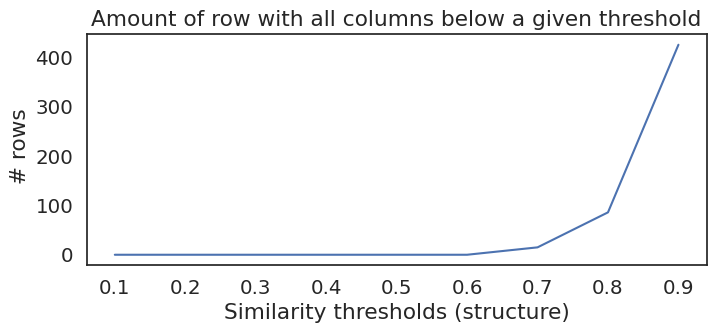

In [94]:
thresholds = np.linspace(0, 1, 11)[1:-1]

struc_sim.values[tuple([range(len(struc_sim))]*2)] = 0
plt.figure(figsize=(8,3))
plt.plot(thresholds, [(struc_sim < t).all(axis=1).sum() for t in thresholds])
plt.xlabel("Similarity thresholds (structure)")
plt.ylabel(" # rows")
plt.title("Amount of row with all columns below a given threshold")

In [87]:
fam_order = ["grp1", "tmRNA", "tRNA", "5s", "srp", "telomerase", "RNaseP", "16s", "23s"]

def plot_families(fam, no_similar, max_sim):
    # plot the distribution of the families
    counts = fam.groupby("family").count()
    #counts = counts/max(counts)
    cc = pd.DataFrame(counts)
    xorder2 = fam_order #list(cc.index)
    for f in fam_order:
        if f not in cc.index:
            cc.loc[f] = 0
    cc = cc.rename(columns={"len": "count"})

    fig = sns.set(rc={'figure.figsize':(18,5)})
    sns.set(font_scale=1.3)
    sns.set_style(style='white')
    fig = plt.figure(figsize=(18,5))
    bp = sns.barplot(data=cc, y="count", x=cc.index, order=xorder2,
                    facecolor=(0.0,0.0,1.0,0.1), linewidth=1,
                    edgecolor=(0.0,0.0,1.0,0.3), zorder=-1)
    bp.set_title(f"Similarity < {max_sim:.2} - {len(no_similar)} sequences - length: {fam.len.min():.0f} < {fam.len.mean():.0f} < {fam.len.max():.0f}")


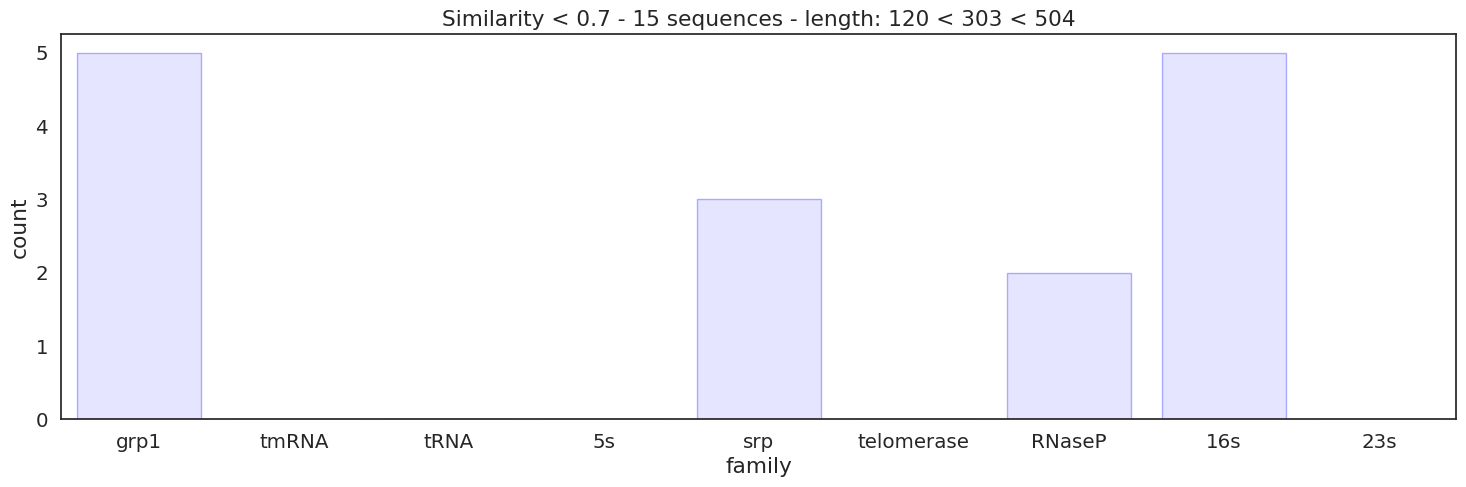

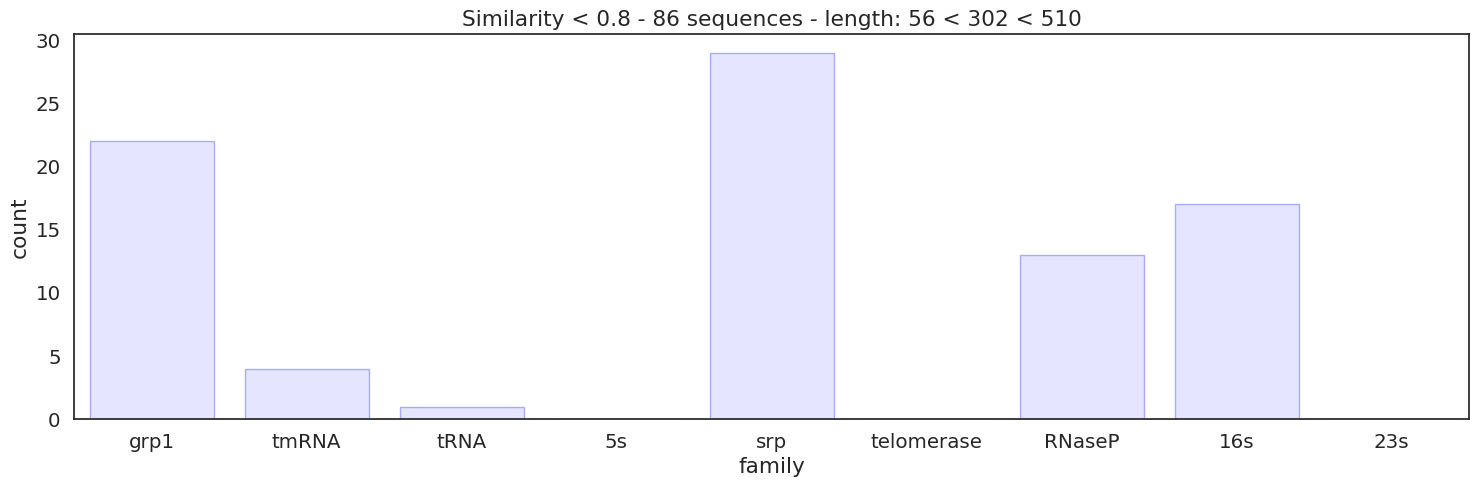

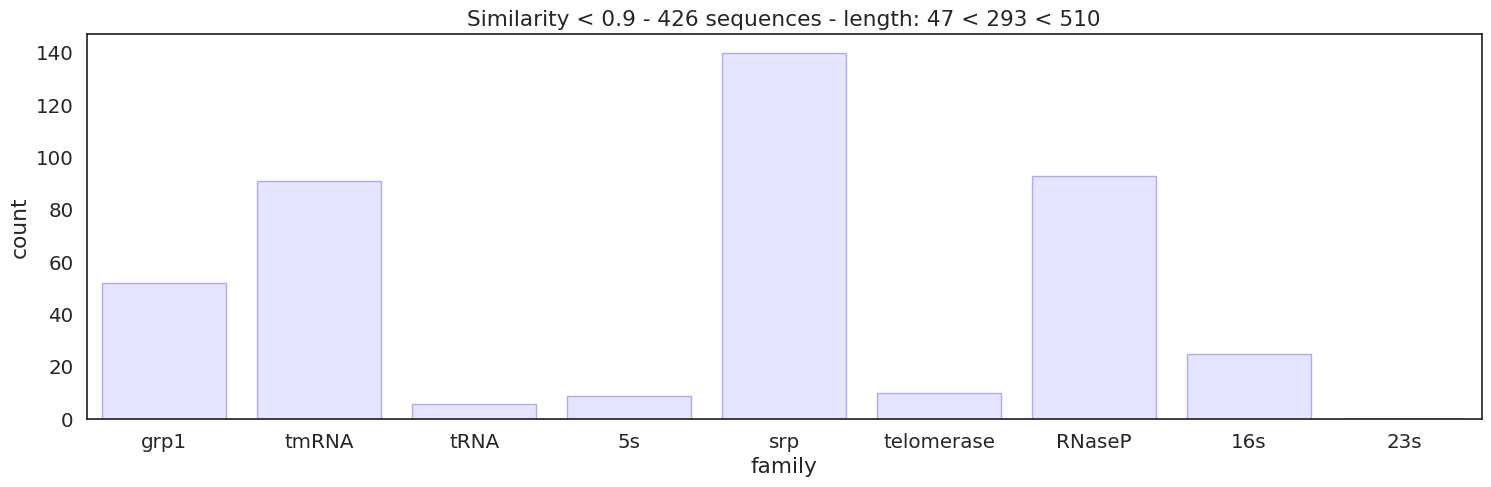

In [37]:
# set the diagonal to 0, to exclude the similarity of a sequence with itself
struc_sim.values[tuple([range(len(struc_sim))]*2)] = 0

splits = []

thresholds = np.linspace(0, 1, 11)[1:-1]
# for each threshold, extract the rows for which similarities in all columns are below that threshold
for max_sim in thresholds:
    max_sim_int = int(max_sim*100)
    no_similar = list(struc_sim[(struc_sim < max_sim).all(axis=1)].index)

    # Save CSV whit the sequences, structures and base pairs (not required, only splits are needed)
    # dataset.loc[no_similar].to_csv(f"gendata/archiveII_similars_up_to_thr_{max_sim_int}.csv")

    fam = pd.DataFrame(no_similar, columns=["id"])
    fam = fam.set_index("id")
    if len(fam) > 0:
        # extract the family name from the id
        fam.insert(loc=0, column='family', value=[id.split("_")[0] for id in fam.index])
        fam.insert(loc=1, column="len", value=dataset.len)

        # plot the distribution of the families
        plot_families(fam, no_similar, max_sim)


#     rows = []
#     for k in range(10):
#         train, test = train_test_split(fam, test_size=0.2, random_state=3003+k)
#         train, valid = train_test_split(train, test_size=0.2, random_state=3003+k)

#         fold_number = k
#         split_type = f"sim{max_sim_int}-fold"

#         rows.append(pd.DataFrame({
#             "split_type": split_type,
#             "fold_name": fold_number,
#             "fold_number": fold_number,
#             "partition": "train",
#             "id": train.index
#         }))

#         rows.append(pd.DataFrame({
#             "split_type": split_type,
#             "fold_name": fold_number,
#             "fold_number": fold_number,
#             "partition": "valid",
#             "id": valid.index
#         }))

#         rows.append(pd.DataFrame({
#             "split_type": split_type,
#             "fold_name": fold_number,
#             "fold_number": fold_number,
#             "partition": "test",
#             "id": test.index
#         }))

#     split_max_sim = pd.concat(rows, ignore_index=True)
#     splits.append(split_max_sim)


# splits = pd.concat(splits)
# #splits.to_csv(f"{DATA_PATH}archiveII_similars_splits_less_than_512.csv", index=False)
# splits

In [ ]:
# load the splits
splits2 = pd.read_csv(f"{DATA_PATH}archiveII_similars_splits_less_than_512.csv")

# separate in one csv per split_type
split_types = splits2.split_type.unique()
for split_type in split_types:
    # save without the column split_type
    splits2.loc[splits2.split_type == split_type].drop(columns="split_type").to_csv(f"{DATA_PATH}archiveII_similars_splits_less_than_512_k10_boostrap_{split_type}.csv", index=False)
    #splits2.loc[splits2.split_type == split_type].to_csv(f"{DATA_PATH}archiveII_similars_splits_less_than_512_{split_type}.csv", index=False)
